In [70]:
import geopandas as gpd
import pandas as pd
from dist_s1_enumerator import get_mgrs_table, get_burst_table
import requests
import matplotlib.pyplot as plt
import contextily as ctx

This is the mgrs table in our enumerator.

In [71]:
df_mgrs_dist_s1 = get_mgrs_table()

And this is the global set of MGRS tiles

In [72]:
df_mgrs_all = gpd.read_file('https://raw.githubusercontent.com/NASA-IMPACT/hls-land_tiles/refs/heads/master/s2_grid.json')

We also have a list from DIST-HLS team (Amy Pickenson) with HLS tiles processed.

In [73]:
resp = requests.get('https://raw.githubusercontent.com/OPERA-Cal-Val/dist-s1-research/refs/heads/dev/marshak/R_mgrs_burst_lookup/dist_hls_tiles.txt')
hls_tiles_in_dist_hls = resp.text.split('\n')
hls_tiles_in_dist_hls[:10]

['01RGJ',
 '01RFL',
 '01REL',
 '01RDM',
 '01RCM',
 '01RHJ',
 '01GEL',
 '01GEM',
 '01GDM',
 '01GBH']

In [74]:
len(hls_tiles_in_dist_hls), df_mgrs_dist_s1.shape

(19048, (19043, 4))

There appears to be 5 missing tiles, what are they?

In [75]:
mgrs_tiles_in_dist_s1 = df_mgrs_dist_s1.mgrs_tile_id.tolist()
missing_mgrs_tiles_from_amy_list = [mid for mid in hls_tiles_in_dist_hls if mid not in mgrs_tiles_in_dist_s1]
missing_mgrs_tiles_from_amy_list

['44976', '45128', '45098', '45086', '']

Well it looks like the list has invalid tile ids. So we can ignore these 5 (including the empty string - which is probably just empty line at end of file).

Let's make sure all the mgrs tiles are really in the list still.

In [76]:
[mid for mid in mgrs_tiles_in_dist_s1 if mid not in hls_tiles_in_dist_hls]

[]

That's reassuring - so the counting was correct. Now lets check all valid MGRS tiles and see what we are excluding.

In [77]:
df_mgrs_all = gpd.read_file('https://raw.githubusercontent.com/NASA-IMPACT/hls-land_tiles/refs/heads/master/s2_grid.json')
df_mgrs_all = df_mgrs_all.rename(columns={'identifier': 'mgrs_tile_id'})

In [78]:
all_mgrs_tile_ids = df_mgrs_all.mgrs_tile_id.tolist()
missing_mgrs_tiles_from_entire_set = list((set(all_mgrs_tile_ids).difference(set(mgrs_tiles_in_dist_s1))))
len(missing_mgrs_tiles_from_entire_set), len(all_mgrs_tile_ids)

(37643, 56686)

In [79]:
missing_mgrs_tiles_from_entire_set[:10]

['48HYJ',
 '40GFA',
 '07UET',
 '57GVN',
 '26UMG',
 '07XEA',
 '08JNT',
 '12NTP',
 '44LPQ',
 '13JFJ']

<Axes: >

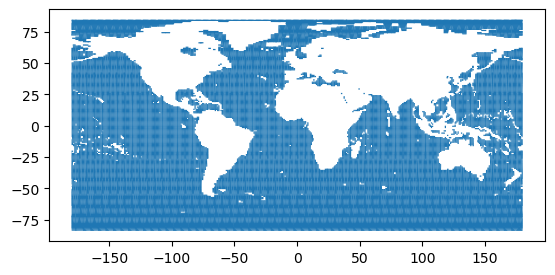

In [80]:
df_mgrs_dist_s1_missing = df_mgrs_all[df_mgrs_all.mgrs_tile_id.isin(missing_mgrs_tiles_from_entire_set)].reset_index()
df_mgrs_dist_s1_missing.plot()

So a majority of the tiles are missing over the ocean. So indeed if we are given a list of MGRS tiles, we can assume those are not valid.

## Burst ID Analysis

In [110]:
df_burst_all_land = gpd.read_parquet('jpl_burst_geo.parquet')
df_burst_all_land.head()

,jpl_burst_id,geometry
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.38755 5.26068, 4...."
1,T001-000027-IW3,"POLYGON ((3.95778 5.52153, 4.31898 5.5935, 4.6..."
2,T001-000030-IW3,"POLYGON ((3.85573 6.02123, 4.21726 6.09294, 4...."
3,T001-000031-IW3,"POLYGON ((3.82176 6.1878, 4.18341 6.25942, 4.5..."
4,T001-000032-IW2,"POLYGON ((3.01846 6.14155, 3.43161 6.22449, 3...."


In [111]:
df_burst_all = gpd.read_file('../Zb_update_burst_table/opera-s1-disp-0.12.0.gpkg')
df_burst_all.head()

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'opera-s1-disp-0.12.0.gpkg': 'burst_id_map' (default), 'frames', 'frames_bursts', 'metadata'. Specify layer parameter to avoid this warning.
  result = read_func(


,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,burst_id_jpl,epsg,is_north_america,xmin,ymin,xmax,ymax,geometry
0,1,IW1,1,2.301015,ASCENDING,t001_000001_iw1,32631,False,531360,78240,630690,128280,"MULTIPOLYGON Z (((3.36758 0.75322 0, 3.763 0.8..."
1,1,IW2,1,3.133218,ASCENDING,t001_000001_iw2,32631,False,612180,102660,715320,152370,"MULTIPOLYGON Z (((4.09178 0.97402 0, 4.50253 1..."
2,1,IW3,1,4.211255,ASCENDING,t001_000001_iw3,32631,False,696870,126810,789960,175590,"MULTIPOLYGON Z (((4.85545 1.192 0, 5.21485 1.2..."
3,2,IW1,1,5.059288,ASCENDING,t001_000002_iw1,32631,False,527460,96690,626820,146730,"MULTIPOLYGON Z (((3.33269 0.92005 0, 3.7281 1...."
4,2,IW2,1,5.891491,ASCENDING,t001_000002_iw2,32631,False,608280,121080,711450,170760,"MULTIPOLYGON Z (((4.0569 1.14071 0, 4.46766 1...."


In [112]:
df_burst_all['jpl_burst_id'] = df_burst_all.burst_id_jpl.str.upper()
df_burst_all['jpl_burst_id'] = df_burst_all['jpl_burst_id'].str.replace('_', '-')
df_burst_all.head()

,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,burst_id_jpl,epsg,is_north_america,xmin,ymin,xmax,ymax,geometry,jpl_burst_id
0,1,IW1,1,2.301015,ASCENDING,t001_000001_iw1,32631,False,531360,78240,630690,128280,"MULTIPOLYGON Z (((3.36758 0.75322 0, 3.763 0.8...",T001-000001-IW1
1,1,IW2,1,3.133218,ASCENDING,t001_000001_iw2,32631,False,612180,102660,715320,152370,"MULTIPOLYGON Z (((4.09178 0.97402 0, 4.50253 1...",T001-000001-IW2
2,1,IW3,1,4.211255,ASCENDING,t001_000001_iw3,32631,False,696870,126810,789960,175590,"MULTIPOLYGON Z (((4.85545 1.192 0, 5.21485 1.2...",T001-000001-IW3
3,2,IW1,1,5.059288,ASCENDING,t001_000002_iw1,32631,False,527460,96690,626820,146730,"MULTIPOLYGON Z (((3.33269 0.92005 0, 3.7281 1....",T001-000002-IW1
4,2,IW2,1,5.891491,ASCENDING,t001_000002_iw2,32631,False,608280,121080,711450,170760,"MULTIPOLYGON Z (((4.0569 1.14071 0, 4.46766 1....",T001-000002-IW2


In [113]:
with open('burst_ids_missing_tile_20250619_20250620.txt') as f:
    bids_p = f.readlines()

In [114]:
bids_p = list(map(lambda bid: bid.strip(), bids_p))
# bids = list(map(lambda bid: bid.lower(), bids_p))
bids_p[:3]

['T048-102243-IW1', 'T048-102243-IW2', 'T048-102243-IW3']

In [115]:
df_burst_p = df_burst_all[df_burst_all.jpl_burst_id.isin(bids_p)]
df_burst_p.shape

(3169, 14)

In [116]:
len(bids_p)

3169

<Axes: >

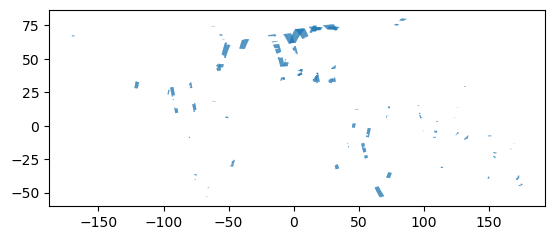

In [117]:
df_burst_p.plot()

Intersection with MGRS tiles that are valid for DIST-S1

In [118]:
df_burst_mgrs_dists1_p = gpd.sjoin(df_burst_p, df_mgrs_dist_s1, predicate='intersects', how='inner').reset_index(drop=True)

In [119]:
df_burst_mgrs_dists1_p.shape

(145, 18)

So of the 3,169 bursts that were viewed as problematic only 145 were over MGRS tiles in DIST-S1.

In [120]:
df_burst_mgrs_dists1_p.head()

,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,burst_id_jpl,epsg,is_north_america,xmin,ymin,xmax,ymax,geometry,jpl_burst_id,index_right,mgrs_tile_id,utm_epsg,utm_wkt
0,104208,IW3,49,3056.131902,DESCENDING,t049_104208_iw3,32740,False,400980,9437610,493980,9486960,"MULTIPOLYGON Z (((56.90041 -4.84778 0, 56.5417...",T049-104208-IW3,11896,40MCV,32740,"MULTIPOLYGON(((300000 9500020,300000 9390220,4..."
1,104209,IW3,49,3058.890175,DESCENDING,t049_104209_iw3,32740,False,396930,9419220,489930,9468600,"MULTIPOLYGON Z (((56.86399 -5.01412 0, 56.5052...",T049-104209-IW3,11896,40MCV,32740,"MULTIPOLYGON(((300000 9500020,300000 9390220,4..."
2,104210,IW3,49,3061.648448,DESCENDING,t049_104210_iw3,32740,False,392880,9400830,485910,9450240,"MULTIPOLYGON Z (((56.82752 -5.18045 0, 56.4687...",T049-104210-IW3,11896,40MCV,32740,"MULTIPOLYGON(((300000 9500020,300000 9390220,4..."
3,104211,IW3,49,3064.406721,DESCENDING,t049_104211_iw3,32740,False,388830,9382440,481860,9431850,"MULTIPOLYGON Z (((56.791 -5.34677 0, 56.4321 -...",T049-104211-IW3,11896,40MCV,32740,"MULTIPOLYGON(((300000 9500020,300000 9390220,4..."
4,104212,IW3,49,3067.164994,DESCENDING,t049_104212_iw3,32740,False,384780,9364050,477810,9413490,"MULTIPOLYGON Z (((56.75443 -5.51309 0, 56.3954...",T049-104212-IW3,11895,40MCU,32740,"MULTIPOLYGON(((300000 9400000,300000 9290200,4..."


In [121]:
df_mgrs_tile_id_plot

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,24VUN,32624,"MULTIPOLYGON(((300000 6800040,300000 6690240,4...","POLYGON ((-42.7325 61.28313, -42.61963 60.2993..."


/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 25 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


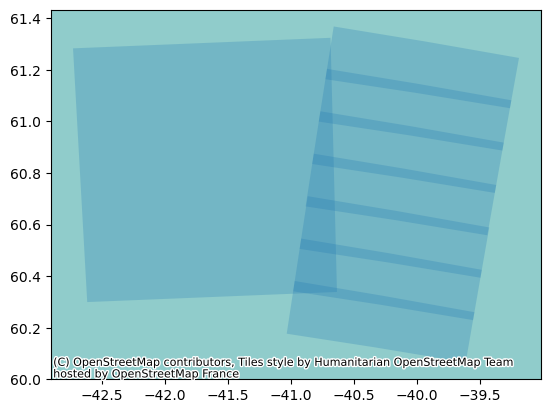

In [122]:
K = 100

fig, ax = plt.subplots()

df_burst_plot = df_burst_mgrs_dists1_p.iloc[K-3: K+4]
df_burst_plot.plot(ax=ax, alpha=.25)

mgrs_tile_id_plot = df_burst_plot.mgrs_tile_id.tolist()[1]
df_mgrs_tile_id_plot = df_mgrs_dist_s1[df_mgrs_dist_s1.mgrs_tile_id == mgrs_tile_id_plot].reset_index(drop=True)
df_mgrs_tile_id_plot.plot(alpha=.25, ax=ax)
ctx.add_basemap(ax)
df_mgrs_tile_id_plot.to_file('wtf.geojson', driver='GeoJSON')

Well - it looks like some of the passes are significant enough and I was concerned about adequate passes particularly for immediate lookback which doesn't matter anymore.

I am going to redo this.

In [123]:
df_burst_old = get_burst_table()
df_burst_old.shape

(383980, 2)

In [124]:
df_burst_new = gpd.read_parquet('jpl_burst_geo.parquet')
df_burst_new.shape

(319554, 2)

In [125]:
[bid for bid in df_burst_mgrs_dists1_p.jpl_burst_id.tolist() if bid not in df_burst_new.jpl_burst_id.tolist()]

['T049-104208-IW3',
 'T049-104209-IW3',
 'T049-104210-IW3',
 'T049-104211-IW3',
 'T049-104212-IW3',
 'T049-104212-IW3',
 'T049-104213-IW3',
 'T049-104214-IW3',
 'T049-104215-IW3',
 'T049-104216-IW2',
 'T049-104216-IW3',
 'T049-104216-IW3',
 'T051-108038-IW2',
 'T051-108039-IW2',
 'T051-108039-IW3',
 'T051-108039-IW3',
 'T051-108039-IW3',
 'T051-108040-IW2',
 'T051-108040-IW3',
 'T051-108040-IW3',
 'T051-108040-IW3',
 'T052-110246-IW1',
 'T052-110246-IW1',
 'T052-110246-IW2',
 'T052-110246-IW2',
 'T052-110247-IW1',
 'T052-110247-IW1',
 'T052-110247-IW2',
 'T052-110247-IW2',
 'T052-110248-IW1',
 'T052-110248-IW1',
 'T052-110248-IW2',
 'T052-110248-IW2',
 'T052-110338-IW1',
 'T052-110338-IW1',
 'T052-110338-IW2',
 'T052-110339-IW1',
 'T052-110339-IW1',
 'T052-110339-IW2',
 'T052-110340-IW1',
 'T052-110340-IW2',
 'T054-114554-IW1',
 'T054-114554-IW1',
 'T054-114554-IW2',
 'T054-114642-IW1',
 'T054-114642-IW2',
 'T054-114642-IW2',
 'T054-114642-IW3',
 'T054-114808-IW3',
 'T058-122630-IW3',
